#Telco Customer Churn

In [1270]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder,PowerTransformer,OrdinalEncoder,OneHotEncoder, StandardScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV

In [1173]:
df = pd.read_csv('https://raw.githubusercontent.com/KarthiObli/TelcoCustomerChurn/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [1174]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [1175]:
df.drop('customerID',axis=1,inplace=True)

In [1176]:
df_corr = df[:]

In [1177]:
le = LabelEncoder()

In [1178]:
for i in df_corr.select_dtypes(include='object').columns:
  df_corr[i] = le.fit_transform(df_corr[i])

In [1179]:
corr = df_corr.corr()

<Axes: >

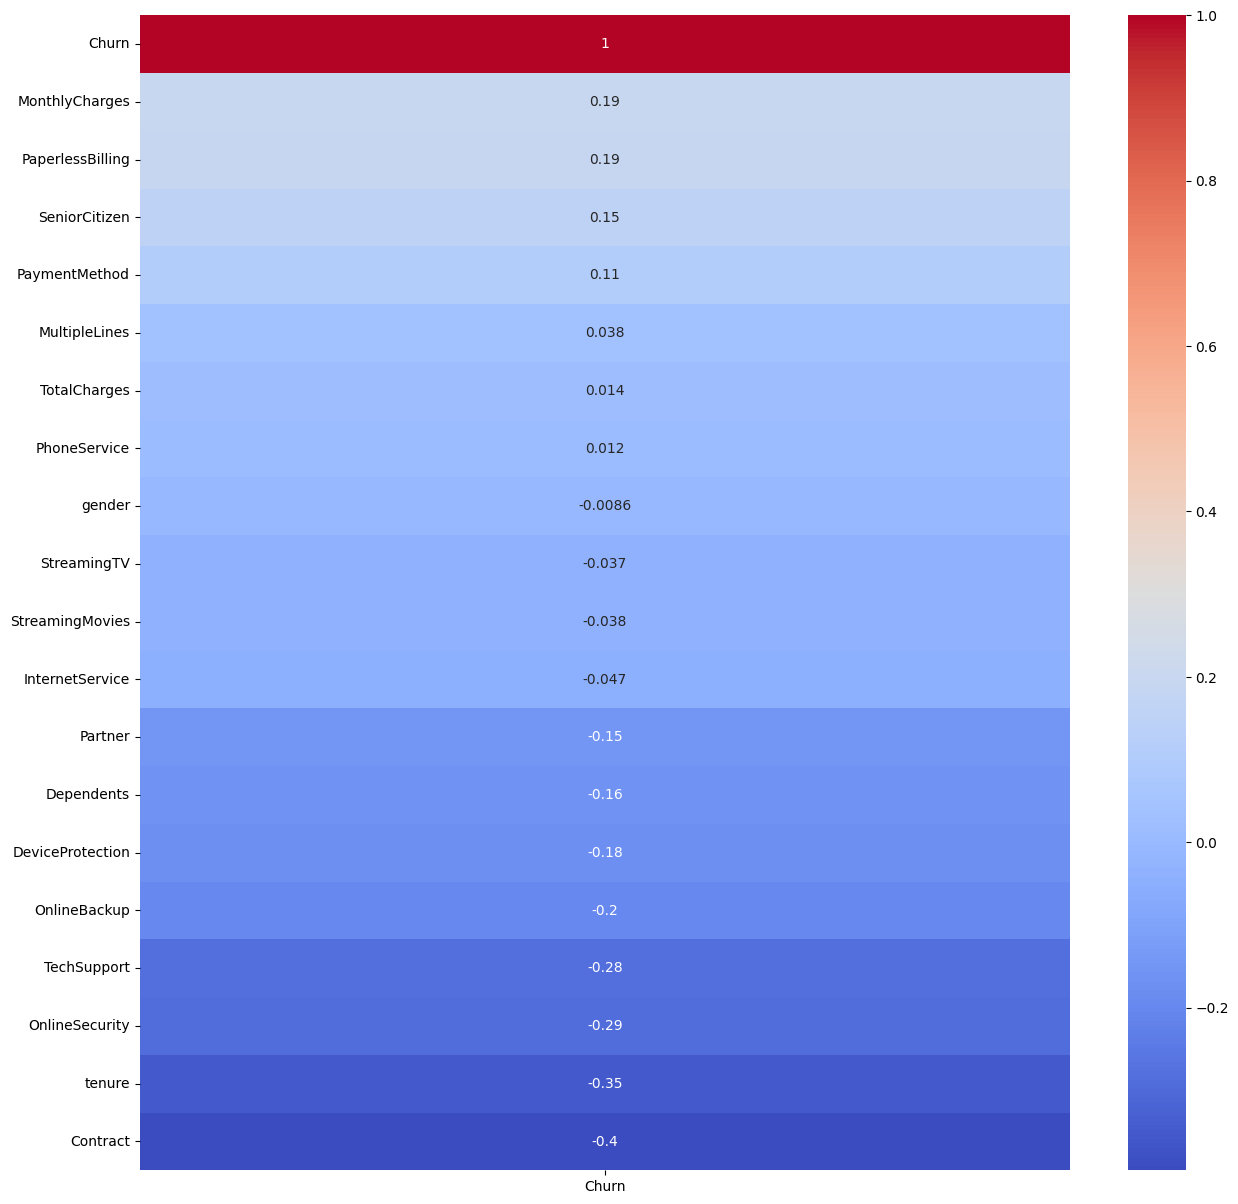

In [1180]:
plt.figure(figsize=(15,15))
sns.heatmap(corr[['Churn']].sort_values(by='Churn',ascending=False),annot=True,cmap='coolwarm')

In [1181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [1182]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(),errors='coerce')

In [1183]:
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [1184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [1185]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [1186]:
df['SeniorCitizen'] = np.where(df['SeniorCitizen']==1,'Yes','No')

##Train Test Split

In [1187]:
x = df.drop('Churn',axis=1)

In [1188]:
y = df[['Churn']]

In [1189]:
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=21,test_size=0.2,stratify=y)

In [1190]:
x_train.reset_index(drop=True,inplace=True)
x_test.reset_index(drop=True,inplace=True)
y_train.reset_index(drop=True,inplace=True)
y_test.reset_index(drop=True,inplace=True)

##Null Handling

In [1191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [1192]:
Impute_Total_Charges = SimpleImputer(strategy = 'mean')
x_train['TotalCharges'] = Impute_Total_Charges.fit_transform(x_train[['TotalCharges']])
x_test['TotalCharges'] = Impute_Total_Charges.fit_transform(x_test[['TotalCharges']])

##Outlier Handling

In [1193]:
x_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,No,No,No,2,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,82.00,184.65
1,Female,No,No,No,34,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Mailed check,109.80,3587.25
2,Female,No,No,No,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,Month-to-month,No,Mailed check,66.25,620.55
3,Male,No,Yes,No,67,Yes,Yes,Fiber optic,No,Yes,Yes,No,No,Yes,Two year,Yes,Electronic check,93.15,6368.20
4,Male,No,No,No,71,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Bank transfer (automatic),53.95,3888.65


In [1194]:
numerical_columns = [i for i in x_train.select_dtypes(['int','float']).columns]

In [1195]:
numerical_columns

['tenure', 'MonthlyCharges', 'TotalCharges']

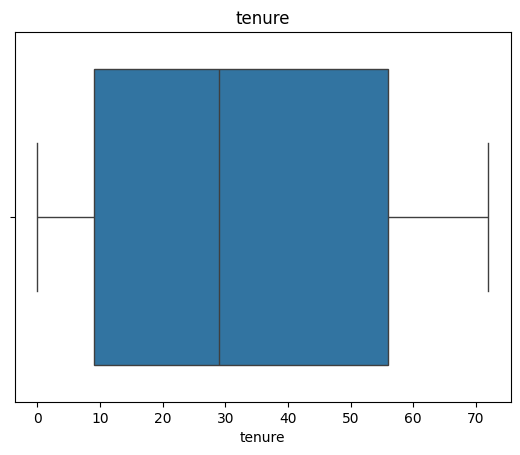

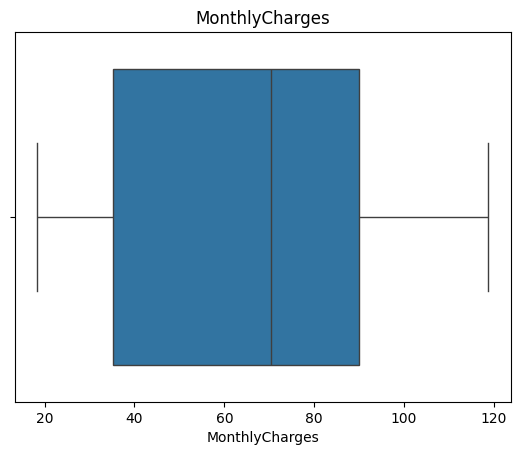

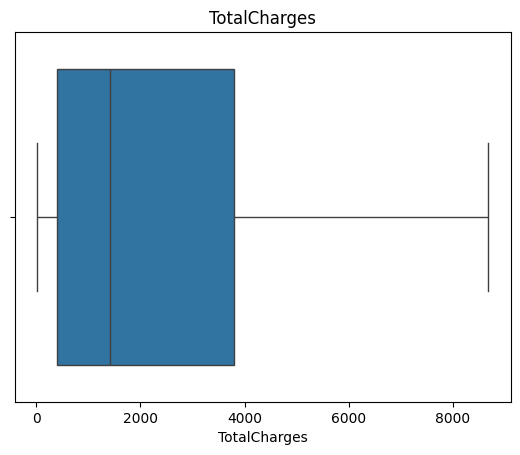

In [1196]:
for i in numerical_columns:
  sns.boxplot(x=x_train[i])
  plt.title(i)
  plt.show()

Outlier handling is not required

##Skew Data handling

/tmp/ipykernel_2582/1145699575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train[i])


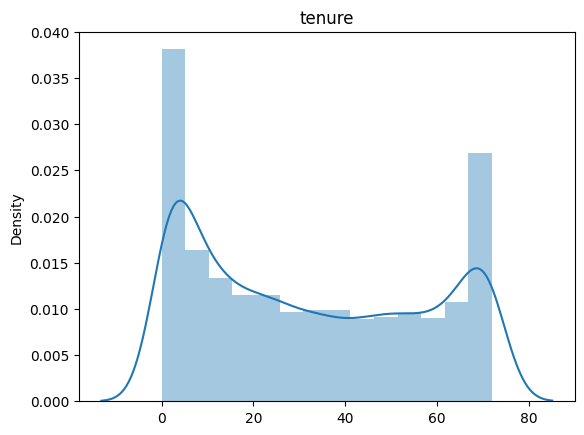

/tmp/ipykernel_2582/1145699575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train[i])


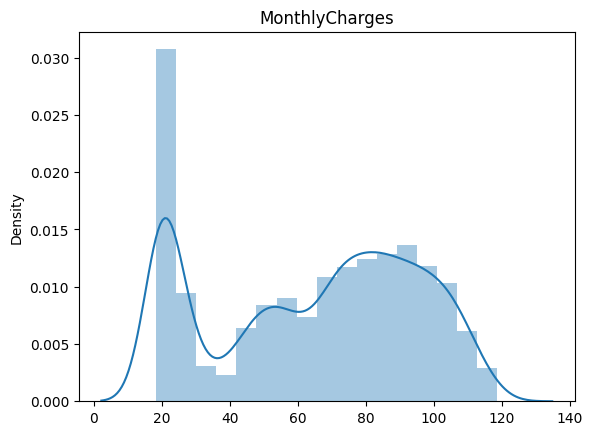

/tmp/ipykernel_2582/1145699575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train[i])


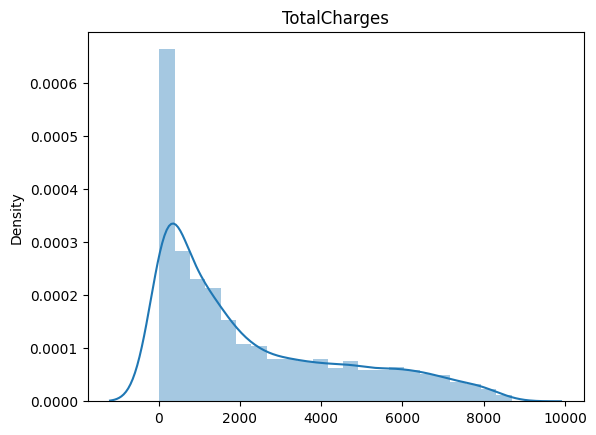

In [1197]:
for i in numerical_columns:
  sns.distplot(x=x_train[i])
  plt.title(i)
  plt.show()

In [1198]:
for i in numerical_columns:
  print(f'Skew of {i} is {x_train[i].skew()}')

Skew of tenure is 0.24154307949177942
Skew of MonthlyCharges is -0.2180067984814727
Skew of TotalCharges is 0.959567310717357


In [1199]:
PT = PowerTransformer(method='yeo-johnson')

In [1200]:
x_train['TotalCharges'] = PT.fit_transform(x_train[['TotalCharges']])

In [1201]:
x_test['TotalCharges'] = PT.transform(x_test[['TotalCharges']])

/tmp/ipykernel_2582/1145699575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train[i])


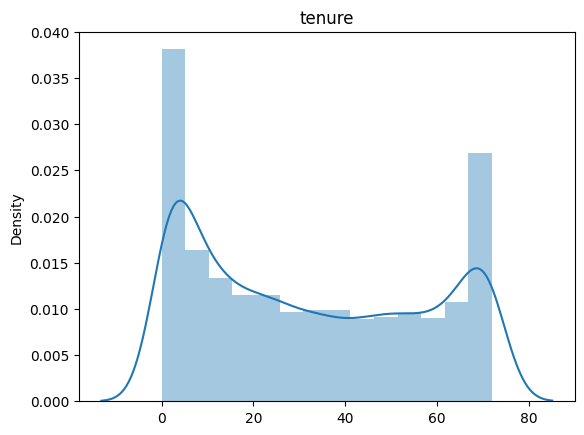

/tmp/ipykernel_2582/1145699575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train[i])


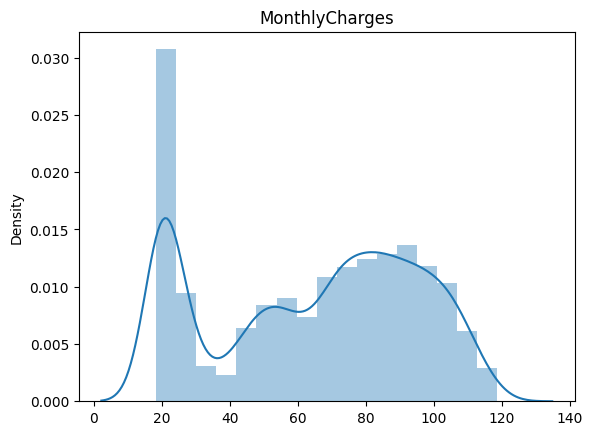

/tmp/ipykernel_2582/1145699575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train[i])


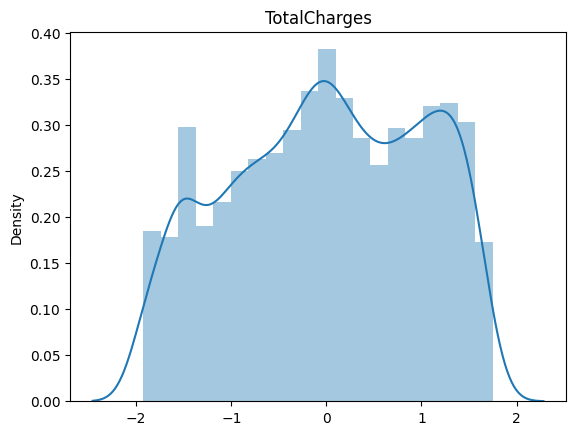

In [1202]:
for i in numerical_columns:
  sns.distplot(x=x_train[i])
  plt.title(i)
  plt.show()

In [1203]:
for i in numerical_columns:
  print(f'Skew of {i} is {x_train[i].skew()}')

Skew of tenure is 0.24154307949177942
Skew of MonthlyCharges is -0.2180067984814727
Skew of TotalCharges is -0.1453161207648667


In [1204]:
x_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,No,No,No,2,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,82.00,-1.161250
1,Female,No,No,No,34,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Mailed check,109.80,0.812024
2,Female,No,No,No,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,Month-to-month,No,Mailed check,66.25,-0.528593
3,Male,No,Yes,No,67,Yes,Yes,Fiber optic,No,Yes,Yes,No,No,Yes,Two year,Yes,Electronic check,93.15,1.396625
4,Male,No,No,No,71,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Bank transfer (automatic),53.95,0.889162


In [1205]:
categorical_columns = [i for i in x_train.select_dtypes('object').columns]

##Encoding and Feature Scaling

In [1206]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   object 
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 


In [1207]:
x_train['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [1208]:
x_train['SeniorCitizen'].unique()

array(['No', 'Yes'], dtype=object)

In [1209]:
x_train['Partner'].unique()

array(['No', 'Yes'], dtype=object)

In [1210]:
x_train['Dependents'].unique()

array(['No', 'Yes'], dtype=object)

In [1211]:
x_train['PhoneService'].unique()

array(['Yes', 'No'], dtype=object)

In [1212]:
x_train['MultipleLines'].unique()

array(['Yes', 'No', 'No phone service'], dtype=object)

In [1213]:
x_train['InternetService'].unique()

array(['Fiber optic', 'DSL', 'No'], dtype=object)

In [1214]:
x_train['OnlineSecurity'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [1215]:
x_train['OnlineBackup'].unique()

array(['Yes', 'No internet service', 'No'], dtype=object)

In [1216]:
x_train['DeviceProtection'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [1217]:
x_train['TechSupport'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [1218]:
x_train['StreamingMovies'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [1219]:
x_train['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [1220]:
x_train['PaperlessBilling'].unique()

array(['Yes', 'No'], dtype=object)

In [1221]:
x_train['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [1222]:
x_train['StreamingTV'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [1223]:
ColumnTransformer_Preprocessor = ColumnTransformer([('Ordinal_encoding',OrdinalEncoder(),['gender','SeniorCitizen','Partner','Dependents','PhoneService','PaperlessBilling']),('One_Hot_encoding',OneHotEncoder(),['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingMovies','Contract','PaymentMethod','StreamingTV']),('Standard Scaling',StandardScaler(),['tenure', 'MonthlyCharges', 'TotalCharges'])],remainder = 'passthrough')

In [1224]:
ColumnTransformer_Preprocessor_y = ColumnTransformer([('Encoding',OrdinalEncoder(),['Churn'])],remainder = 'passthrough')

In [1225]:
pipelines = Pipeline([('Preprocessing',ColumnTransformer_Preprocessor)])

In [1226]:
pipelines_y = Pipeline([('Preprocessing_y',ColumnTransformer_Preprocessor_y)])

In [1227]:
x_train = pd.DataFrame(pipelines.fit_transform(x_train),columns=pipelines.named_steps['Preprocessing'].get_feature_names_out())

In [1228]:
x_test = pd.DataFrame(pipelines.transform(x_test),columns=pipelines.named_steps['Preprocessing'].get_feature_names_out())

In [1229]:
y_train = pd.DataFrame(pipelines_y.fit_transform(y_train),columns=pipelines_y.named_steps['Preprocessing_y'].get_feature_names_out())

In [1230]:
y_test = pd.DataFrame(pipelines_y.transform(y_test),columns=pipelines_y.named_steps['Preprocessing_y'].get_feature_names_out())

In [1231]:
x_train.head()

,Ordinal_encoding__gender,Ordinal_encoding__SeniorCitizen,Ordinal_encoding__Partner,Ordinal_encoding__Dependents,Ordinal_encoding__PhoneService,Ordinal_encoding__PaperlessBilling,One_Hot_encoding__MultipleLines_No,One_Hot_encoding__MultipleLines_No phone service,One_Hot_encoding__MultipleLines_Yes,One_Hot_encoding__InternetService_DSL,...,One_Hot_encoding__PaymentMethod_Bank transfer (automatic),One_Hot_encoding__PaymentMethod_Credit card (automatic),One_Hot_encoding__PaymentMethod_Electronic check,One_Hot_encoding__PaymentMethod_Mailed check,One_Hot_encoding__StreamingTV_No,One_Hot_encoding__StreamingTV_No internet service,One_Hot_encoding__StreamingTV_Yes,Standard Scaling__tenure,Standard Scaling__MonthlyCharges,Standard Scaling__TotalCharges
0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,-1.235006,0.571533,-1.161250
1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.063208,1.492291,0.812024
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.951022,0.049880,-0.528593
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.401993,0.940830,1.396625
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.564270,-0.357506,0.889162


##Imbalanced data handling

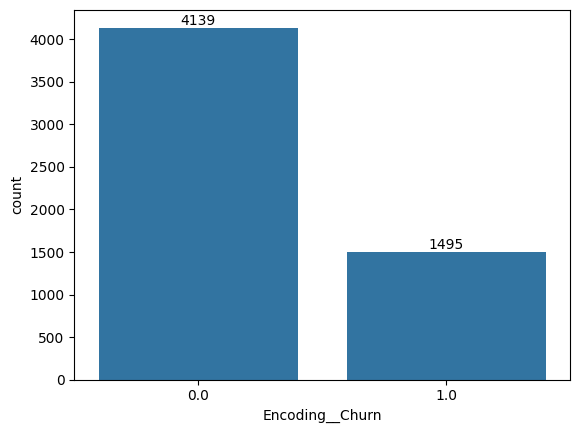

In [1232]:
plot = sns.countplot(x=y_train['Encoding__Churn'])
for i in plot.containers:
  plot.bar_label(i)

In [1233]:
SMOTE_Churn = SMOTE()

In [1234]:
x_train, y_train = SMOTE_Churn.fit_resample(x_train,y_train)

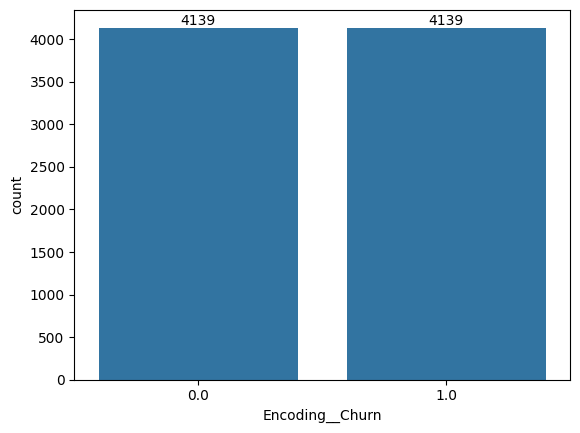

In [1235]:
plot = sns.countplot(x=y_train['Encoding__Churn'])
for i in plot.containers:
  plot.bar_label(i)

##Base model Creation

In [1236]:
RF_Base_Model = RandomForestClassifier(max_depth = 10, criterion='gini', max_leaf_nodes=20, n_estimators = 200, oob_score = True, random_state = 21)

In [1237]:
RF_Base_Model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=10, max_leaf_nodes=20, n_estimators=200,
                       oob_score=True, random_state=21)

In [1238]:
RF_Base_Model.score(x_train,y_train)

0.7965692196182653

In [1239]:
RF_Base_Model.score(x_test,y_test)

0.7565649396735273

In [1240]:
y_train_pred = RF_Base_Model.predict(x_train)

In [1241]:
y_pred = RF_Base_Model.predict(x_test)

In [1242]:
precision_score(y_train,y_train_pred)

0.7875380651206372

In [1243]:
precision_score(y_test,y_pred)

0.5294117647058824

In [1244]:
recall_score(y_train,y_train_pred)

0.8122734960135298

In [1245]:
recall_score(y_test,y_pred)

0.7459893048128342

##Hyper parameter tuning

In [1246]:
params = {'max_depth':[i for i in range(5,25)], 'max_leaf_nodes':[i for i in range(5,10)], 'criterion':['gini','entropy'], 'n_estimators':[i for i in range(50,500,50)]}

In [1247]:
RandomSearch = RandomizedSearchCV(estimator = RandomForestClassifier(), param_distributions = params, cv = 5, n_iter = 25, random_state = 21, return_train_score = True,scoring='recall')

In [1248]:
RandomSearch.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=25,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [5, 6, 7, 8, 9, 10, 11, 12,
                                                      13, 14, 15, 16, 17, 18,
                                                      19, 20, 21, 22, 23, 24],
                                        'max_leaf_nodes': [5, 6, 7, 8, 9],
                                        'n_estimators': [50, 100, 150, 200, 250,
                                                         300, 350, 400, 450]},
                   random_state=21, return_train_score=True, scoring='recall')

In [1249]:
results = pd.DataFrame(RandomSearch.cv_results_)

In [1250]:
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_max_leaf_nodes,param_max_depth,param_criterion,params,split0_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,1.819373,0.218241,0.063278,0.014209,450,5,9,gini,"{'n_estimators': 450, 'max_leaf_nodes': 5, 'ma...",0.776570,...,0.810104,0.027936,3,0.811235,0.820900,0.816672,0.821504,0.810085,0.816079,0.004742
1,0.839177,0.293947,0.026872,0.000257,150,9,12,entropy,"{'n_estimators': 150, 'max_leaf_nodes': 9, 'ma...",0.770531,...,0.805273,0.031741,16,0.815464,0.818786,0.815766,0.811537,0.808877,0.814086,0.003477
2,1.259641,0.222977,0.046093,0.011335,250,7,24,entropy,"{'n_estimators': 250, 'max_leaf_nodes': 7, 'ma...",0.777778,...,0.807205,0.028399,7,0.815162,0.817276,0.817276,0.809121,0.814614,0.814690,0.002987
3,0.805039,0.023801,0.029458,0.000619,200,5,22,entropy,"{'n_estimators': 200, 'max_leaf_nodes': 5, 'ma...",0.786232,...,0.813487,0.024842,2,0.817578,0.825430,0.819088,0.813953,0.809481,0.817106,0.005320
4,1.638025,0.223832,0.058862,0.009897,350,9,16,gini,"{'n_estimators': 350, 'max_leaf_nodes': 9, 'ma...",0.756039,...,0.801891,0.033228,23,0.803685,0.818484,0.811235,0.808517,0.809783,0.810341,0.004797


In [1251]:
results[['param_n_estimators','param_max_leaf_nodes','param_max_depth','param_criterion','mean_train_score','mean_test_score']].sort_values(by=['mean_test_score'],ascending=[False])

,param_n_estimators,param_max_leaf_nodes,param_max_depth,param_criterion,mean_train_score,mean_test_score
7,300,5,7,entropy,0.823146,0.814695
3,200,5,22,entropy,0.817106,0.813487
0,450,5,9,gini,0.816079,0.810104
22,350,7,17,entropy,0.817831,0.809863
20,50,8,22,entropy,0.813482,0.809379
18,200,6,9,entropy,0.815837,0.808657
5,400,7,22,entropy,0.815052,0.807205
2,250,7,24,entropy,0.814690,0.807205
11,50,6,6,gini,0.812152,0.806965
16,250,9,22,entropy,0.814871,0.806481


In [1252]:
best_params = RandomSearch.best_params_

In [1253]:
RF = RandomForestClassifier(**best_params,random_state=21)

In [1254]:
RF.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(criterion='entropy', max_depth=7, max_leaf_nodes=5,
                       n_estimators=300, random_state=21)

In [1255]:
y_pred = RF.predict(x_test)

In [1256]:
recall_score(y_pred,y_test)

0.49246231155778897

## Treshold configuration

In [1257]:
y_prob = RF.predict_proba(x_test)[:,1]

In [1258]:
treshold = np.arange(0.1,0.9,0.1)

In [1259]:
for i in treshold:
  y_tresh_predict = (y_prob >= i).astype(int)
  print(f'Treshold : {i}')
  print(f'recall score :{recall_score(y_test,y_tresh_predict)}')
  print(f'recall score :{recall_score(y_test,y_tresh_predict)}')
  print()


Treshold : 0.1
recall score :1.0
recall score :1.0

Treshold : 0.2
recall score :0.9812834224598931
recall score :0.9812834224598931

Treshold : 0.30000000000000004
recall score :0.9572192513368984
recall score :0.9572192513368984

Treshold : 0.4
recall score :0.8636363636363636
recall score :0.8636363636363636

Treshold : 0.5
recall score :0.786096256684492
recall score :0.786096256684492

Treshold : 0.6
recall score :0.6550802139037433
recall score :0.6550802139037433

Treshold : 0.7000000000000001
recall score :0.36363636363636365
recall score :0.36363636363636365

Treshold : 0.8
recall score :0.0
recall score :0.0



Let the new treshold be 0.3

In [1260]:
y_train_prob = RF.predict_proba(x_train)[:,1]

In [1261]:
y_train_predict = (y_train_prob >= .3).astype(int)

In [1262]:
recall_score(y_train,y_train_predict)

0.9664170089393573

In [1263]:
y_predict = (y_prob >= .3).astype(int)

In [1264]:
recall_score(y_test,y_predict)

0.9572192513368984

##Confusion Matrix

In [1269]:
cm = confusion_matrix(y_test,y_pred)

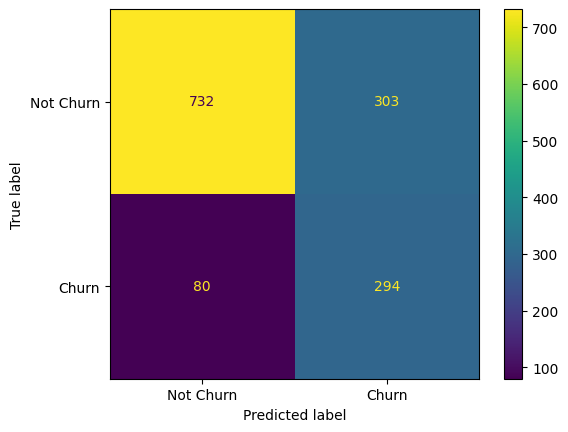

In [1282]:
ConfusionMatrixDisplay(cm,display_labels=['Not Churn','Churn']).plot()
plt.show()

After reducing the classification threshold to 0.3, the churn model became much better at identifying actual churn customers. The test recall increased to ~95.7%, which means the model is now able to correctly capture almost all churn cases. From the confusion matrix, the model correctly identified 294 churn customers and missed only 80 churn customers (false negatives), which is a strong outcome for a churn prediction problem where missing a churner is costly.

However, this improvement in recall comes with a trade-off: the model now produces more false positives — 303 non-churn customers were incorrectly predicted as churners. So the model is now highly aggressive in predicting churn, which is useful when the business goal is to minimize missed churn customers, even if it means targeting some customers who would not actually churn.

Overall conclusion: with a threshold of 0.3, the model is well-suited for churn prevention use cases where recall is the priority, because it captures most potential churners, but it sacrifices precision by increasing false alarms.